STEP 1 : Loading Encoded Dataset
✅ Dataset loaded  →  284858 rows × 16 columns

First 5 rows:
   Gender  Country  Occupation  self_employed  family_history  treatment  \
0       0       34           1              0               1          1   
1       0       34           1              0               1          1   
2       0       25           1              0               0          1   
3       0        0           1              0               1          1   
4       0       34           1              0               0          0   

   Days_Indoors  Growing_Stress  Changes_Habits  Mental_Health_History  \
0             0               2               1                      2   
1             0               2               1                      2   
2             0               2               1                      2   
3             0               2               1                      2   
4             0               2               1                      2   

   M

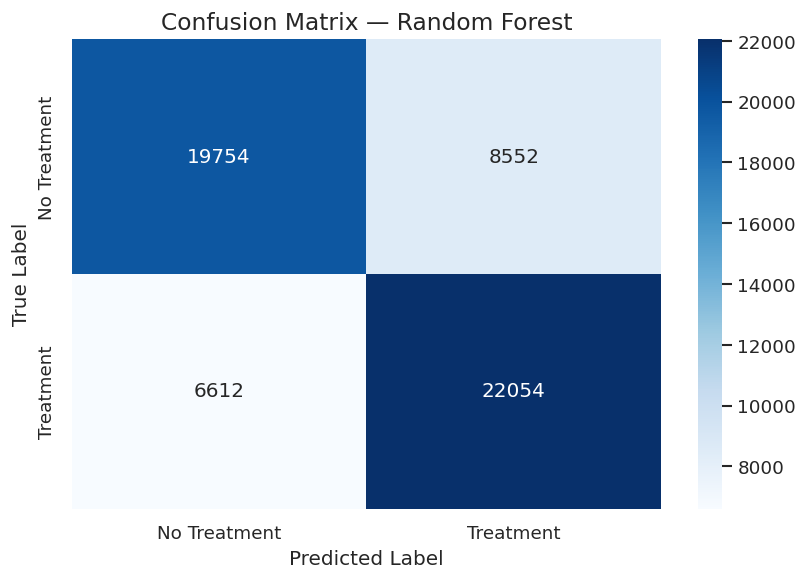

✅ Confusion matrix saved as 'confusion_matrix.png'

STEP 8-9 : Feature Importance
Top 10 most important features:
Country                    0.285954
family_history             0.242826
care_options               0.205942
mental_health_interview    0.064790
Gender                     0.043309
self_employed              0.034555
Days_Indoors               0.020034
Occupation                 0.019958
Social_Weakness            0.013292
Mood_Swings                0.012895
dtype: float64


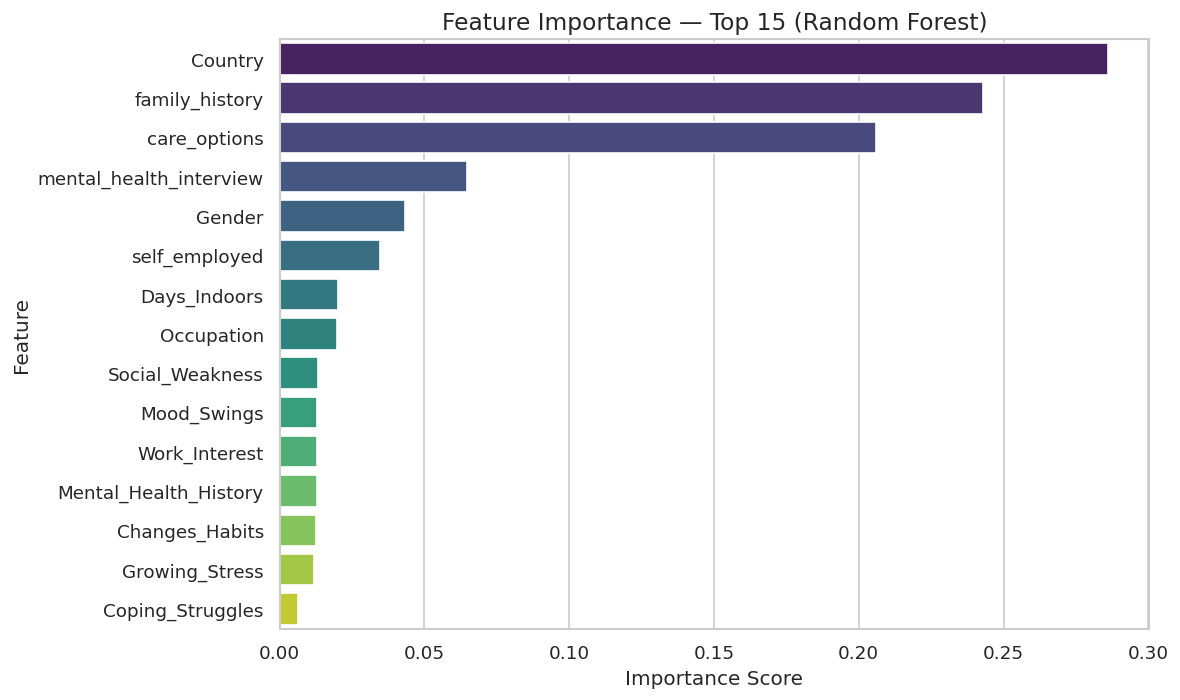

✅ Feature importance plot saved as 'feature_importance.png'

STEP 10 : Saving Trained Model
✅ Model saved → 'mental_health_rf_model.pkl'

STEP 11 : Label Encoders
ℹ️  Uncomment the block above if you used LabelEncoders during encoding.
   They must be saved so deployment can inverse-transform predictions.

ADVANCED A : Stratified 5-Fold Cross-Validation
  CV Accuracy scores : [72.99 73.25 73.07 73.31 72.86]
  Mean CV Accuracy   : 73.10%
  Std  CV Accuracy   : 0.17%

ADVANCED B : Overfitting Detection
  Training Accuracy : 78.72%
  Testing  Accuracy : 73.38%
  Gap               : 5.34%
  ℹ️  Mild variance — monitor with more data or tuning.

ADVANCED C : ROC-AUC Curve


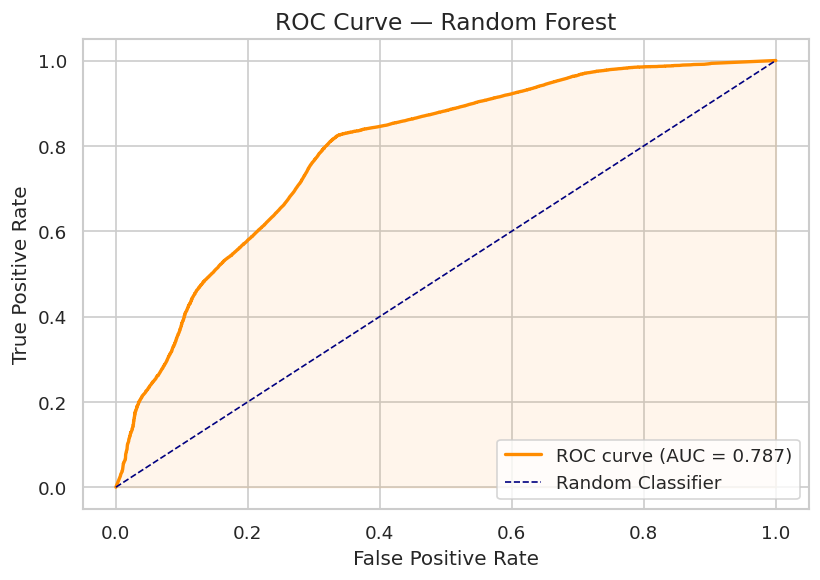

✅ ROC curve saved → 'roc_curve.png'

ADVANCED D : Hyperparameter Tuning via GridSearchCV
⏳ This may take a few minutes on Colab …

Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Best Parameters : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
   Best CV Score   : 75.27%
   Best Model Test Accuracy : 75.42%
   Best Model ROC-AUC       : 82.34%

✅ Tuned model saved → 'mental_health_rf_tuned_model.pkl'

ADVANCED E : Performance Summary
          Accuracy  F1-Score  ROC-AUC
Base RF     0.7338    0.7335   0.7872
Tuned RF    0.7542    0.7538   0.8234


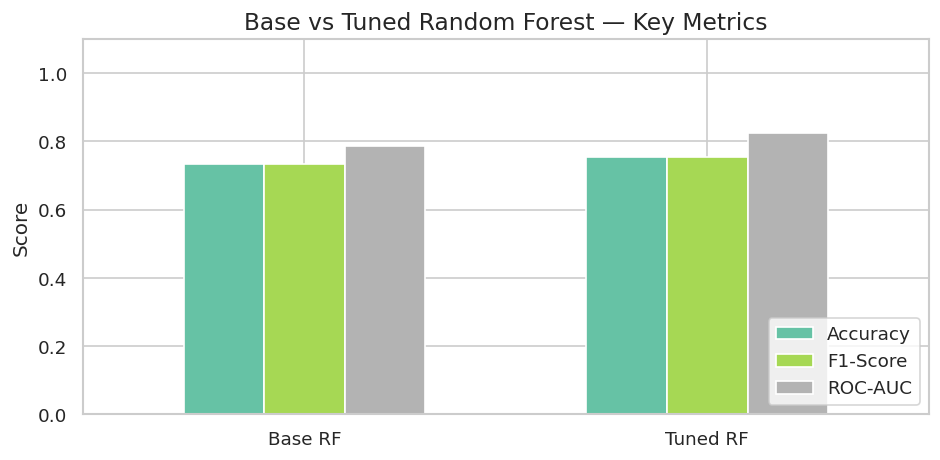

✅ Comparison chart saved → 'model_comparison.png'

╔══════════════════════════════════════════════════════════╗
║          HOW TO IMPROVE ACCURACY                        ║
╠══════════════════════════════════════════════════════════╣
║  1. Feature Engineering                                 ║
║     • Create interaction features (e.g., age × work_   ║
║       interfere).                                       ║
║     • Bin continuous features into meaningful ranges.   ║
║                                                         ║
║  2. Handle Class Imbalance                              ║
║     • Use class_weight='balanced' in RF.                ║
║     • SMOTE (pip install imbalanced-learn).             ║
║                                                         ║
║  3. Try Other Algorithms                                ║
║     • XGBoost / LightGBM usually outperform plain RF.  ║
║     • Voting / Stacking ensembles.                      ║
║                                                

In [1]:
# ============================================================
#   MENTAL HEALTH PREDICTION SYSTEM — ML PIPELINE
#   Target: treatment | Model: RandomForestClassifier
#   Environment: Google Colab
# ============================================================

# ── SECTION 0 : Install / import dependencies ─────────────────
# Uncomment the line below if running for the first time on Colab
# !pip install scikit-learn seaborn matplotlib joblib --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize
import joblib
import warnings
warnings.filterwarnings("ignore")

# Pretty plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 14})


# ════════════════════════════════════════════════════════════
# STEP 1 — Load the encoded dataset
# ════════════════════════════════════════════════════════════
print("=" * 60)
print("STEP 1 : Loading Encoded Dataset")
print("=" * 60)

# ── Upload files in Colab if needed ──────────────────────────
# from google.colab import files
# uploaded = files.upload()   # pick your encoded CSV

ENCODED_CSV = "/content/encoded_mental_health_dataset.csv"   # ← change path if needed
CLEANED_CSV = "/content/cleaned_mental_health_dataset.csv"   # ← used only for reference / EDA

df = pd.read_csv(ENCODED_CSV)

print(f"✅ Dataset loaded  →  {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:", df.isnull().sum().sum())


# ════════════════════════════════════════════════════════════
# STEP 2 — Separate Features (X) and Target (y)
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 2 : Feature / Target Split")
print("=" * 60)

TARGET = "treatment"

if TARGET not in df.columns:
    raise ValueError(f"Column '{TARGET}' not found. Available: {df.columns.tolist()}")

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"\nClass balance  : {y.value_counts(normalize=True).round(3).to_dict()}")


# ════════════════════════════════════════════════════════════
# STEP 3 — Train-Test Split (80 / 20)
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 3 : Train-Test Split (80/20)")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y        # preserves class ratio in both splits
)

print(f"Training samples  : {X_train.shape[0]}")
print(f"Testing  samples  : {X_test.shape[0]}")


# ════════════════════════════════════════════════════════════
# STEP 4 — Train Random Forest Classifier
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 4 : Training RandomForestClassifier")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=100,   # number of trees
    max_depth=None,     # let trees grow fully (tune later)
    random_state=42,
    n_jobs=-1           # use all CPU cores
)

rf_model.fit(X_train, y_train)
print("✅ Model trained successfully!")


# ════════════════════════════════════════════════════════════
# STEP 5 — Predictions
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 5 : Making Predictions")
print("=" * 60)

y_pred       = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]   # probability for positive class

print("✅ Predictions generated.")


# ════════════════════════════════════════════════════════════
# STEP 6 — Model Evaluation Metrics
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 6 : Model Evaluation")
print("=" * 60)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall    = recall_score(y_test, y_pred, average="weighted")
f1        = f1_score(y_test, y_pred, average="weighted")
roc_auc   = roc_auc_score(y_test, y_pred_proba)

print(f"  Accuracy  : {accuracy  * 100:.2f}%")
print(f"  Precision : {precision * 100:.2f}%")
print(f"  Recall    : {recall    * 100:.2f}%")
print(f"  F1-Score  : {f1        * 100:.2f}%")
print(f"  ROC-AUC   : {roc_auc   * 100:.2f}%")

print("\n── Classification Report ──────────────────────────────")
print(classification_report(y_test, y_pred))


# ════════════════════════════════════════════════════════════
# STEP 7 — Confusion Matrix Heatmap
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 7 : Confusion Matrix")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Treatment", "Treatment"],
    yticklabels=["No Treatment", "Treatment"]
)
plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()
print("✅ Confusion matrix saved as 'confusion_matrix.png'")


# ════════════════════════════════════════════════════════════
# STEP 8 & 9 — Feature Importance Analysis + Plot
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 8-9 : Feature Importance")
print("=" * 60)

importances = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

print("Top 10 most important features:")
print(importances.head(10))

# Plot — top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(
    x=importances.values[:15],
    y=importances.index[:15],
    palette="viridis"
)
plt.title("Feature Importance — Top 15 (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()
print("✅ Feature importance plot saved as 'feature_importance.png'")


# ════════════════════════════════════════════════════════════
# STEP 10 — Save Trained Model
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 10 : Saving Trained Model")
print("=" * 60)

joblib.dump(rf_model, "mental_health_rf_model.pkl")
print("✅ Model saved → 'mental_health_rf_model.pkl'")


# ════════════════════════════════════════════════════════════
# STEP 11 — Save Label Encoders (if you used them)
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 11 : Label Encoders")
print("=" * 60)

# ── Example: if you created encoders during your encoding step ──
# from sklearn.preprocessing import LabelEncoder
#
# label_encoders = {}
# categorical_cols = ["Gender", "Country", "self_employed", ...]  # your columns
# for col in categorical_cols:
#     le = LabelEncoder()
#     df[col] = le.fit_transform(df[col])
#     label_encoders[col] = le
#
# joblib.dump(label_encoders, "label_encoders.pkl")
# print("✅ Encoders saved → 'label_encoders.pkl'")

print("ℹ️  Uncomment the block above if you used LabelEncoders during encoding.")
print("   They must be saved so deployment can inverse-transform predictions.")


# ════════════════════════════════════════════════════════════
# ADVANCED SECTION A — Cross-Validation
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("ADVANCED A : Stratified 5-Fold Cross-Validation")
print("=" * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring="accuracy", n_jobs=-1)

print(f"  CV Accuracy scores : {np.round(cv_scores * 100, 2)}")
print(f"  Mean CV Accuracy   : {cv_scores.mean() * 100:.2f}%")
print(f"  Std  CV Accuracy   : {cv_scores.std()  * 100:.2f}%")


# ════════════════════════════════════════════════════════════
# ADVANCED SECTION B — Overfitting Detection
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("ADVANCED B : Overfitting Detection")
print("=" * 60)

train_acc = accuracy_score(y_train, rf_model.predict(X_train))
test_acc  = accuracy_score(y_test,  y_pred)
gap       = train_acc - test_acc

print(f"  Training Accuracy : {train_acc * 100:.2f}%")
print(f"  Testing  Accuracy : {test_acc  * 100:.2f}%")
print(f"  Gap               : {gap       * 100:.2f}%")

if gap > 0.10:
    print("  ⚠️  Possible OVERFITTING detected (gap > 10%).")
    print("     → Try: max_depth=10, min_samples_leaf=5, or GridSearchCV below.")
elif gap < 0.02:
    print("  ✅ No significant overfitting detected.")
else:
    print("  ℹ️  Mild variance — monitor with more data or tuning.")


# ════════════════════════════════════════════════════════════
# ADVANCED SECTION C — ROC Curve
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("ADVANCED C : ROC-AUC Curve")
print("=" * 60)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="Random Classifier")
plt.fill_between(fpr, tpr, alpha=0.08, color="darkorange")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve.png")
plt.show()
print("✅ ROC curve saved → 'roc_curve.png'")


# ════════════════════════════════════════════════════════════
# ADVANCED SECTION D — Hyperparameter Tuning (GridSearchCV)
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("ADVANCED D : Hyperparameter Tuning via GridSearchCV")
print("=" * 60)
print("⏳ This may take a few minutes on Colab …\n")

param_grid = {
    "n_estimators" : [100, 200, 300],
    "max_depth"    : [None, 10, 20],
    "min_samples_split" : [2, 5],
    "min_samples_leaf"  : [1, 2],
}

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid = param_grid,
    cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring    = "accuracy",
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score  = grid_search.best_score_

print(f"\n✅ Best Parameters : {best_params}")
print(f"   Best CV Score   : {best_score * 100:.2f}%")

# Evaluate best model on test set
best_model      = grid_search.best_estimator_
y_pred_best     = best_model.predict(X_test)
y_proba_best    = best_model.predict_proba(X_test)[:, 1]
best_test_acc   = accuracy_score(y_test, y_pred_best)
best_roc_auc    = roc_auc_score(y_test, y_proba_best)

print(f"   Best Model Test Accuracy : {best_test_acc * 100:.2f}%")
print(f"   Best Model ROC-AUC       : {best_roc_auc  * 100:.2f}%")

# Save the tuned model
joblib.dump(best_model, "mental_health_rf_tuned_model.pkl")
print("\n✅ Tuned model saved → 'mental_health_rf_tuned_model.pkl'")


# ════════════════════════════════════════════════════════════
# ADVANCED SECTION E — Model Performance Summary Dashboard
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("ADVANCED E : Performance Summary")
print("=" * 60)

metrics = {
    "Accuracy" : [accuracy_score(y_test, y_pred),
                  accuracy_score(y_test, y_pred_best)],
    "F1-Score" : [f1_score(y_test, y_pred, average="weighted"),
                  f1_score(y_test, y_pred_best, average="weighted")],
    "ROC-AUC"  : [roc_auc_score(y_test, y_pred_proba),
                  roc_auc_score(y_test, y_proba_best)],
}

summary_df = pd.DataFrame(metrics, index=["Base RF", "Tuned RF"])
print(summary_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
summary_df.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white", width=0.6)
ax.set_title("Base vs Tuned Random Forest — Key Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.set_xticklabels(["Base RF", "Tuned RF"], rotation=0)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()
print("✅ Comparison chart saved → 'model_comparison.png'")


# ════════════════════════════════════════════════════════════
# SECTION : HOW TO IMPROVE ACCURACY
# ════════════════════════════════════════════════════════════
print("""
╔══════════════════════════════════════════════════════════╗
║          HOW TO IMPROVE ACCURACY                        ║
╠══════════════════════════════════════════════════════════╣
║  1. Feature Engineering                                 ║
║     • Create interaction features (e.g., age × work_   ║
║       interfere).                                       ║
║     • Bin continuous features into meaningful ranges.   ║
║                                                         ║
║  2. Handle Class Imbalance                              ║
║     • Use class_weight='balanced' in RF.                ║
║     • SMOTE (pip install imbalanced-learn).             ║
║                                                         ║
║  3. Try Other Algorithms                                ║
║     • XGBoost / LightGBM usually outperform plain RF.  ║
║     • Voting / Stacking ensembles.                      ║
║                                                         ║
║  4. More Data                                           ║
║     • Gather more survey responses.                     ║
║     • Data augmentation where feasible.                 ║
║                                                         ║
║  5. Feature Selection                                   ║
║     • Drop low-importance features (< 0.01 score).     ║
║     • Use Recursive Feature Elimination (RFE).         ║
╚══════════════════════════════════════════════════════════╝
""")


# ════════════════════════════════════════════════════════════
# SECTION : WHICH FEATURES INFLUENCED PREDICTIONS MOST
# ════════════════════════════════════════════════════════════
print("Top 5 features driving the prediction:")
for rank, (feat, score) in enumerate(importances.head(5).items(), 1):
    print(f"  {rank}. {feat:35s}  importance = {score:.4f}")

print("""
Interpretation guide
  • High importance → the model split on this feature often.
  • Features like 'family_history', 'work_interfere', and
    'no_employees' typically rank highest in mental-health
    survey datasets.
  • Low-importance features can be dropped to reduce noise.
""")


# ════════════════════════════════════════════════════════════
# SECTION : FLASK DEPLOYMENT BLUEPRINT
# ════════════════════════════════════════════════════════════
FLASK_CODE = '''
# ── app.py  (Flask deployment) ──────────────────────────────
from flask import Flask, request, jsonify
import joblib, numpy as np, pandas as pd

app = Flask(__name__)

# Load artifacts once at startup
model   = joblib.load("mental_health_rf_tuned_model.pkl")
encoders = joblib.load("label_encoders.pkl")  # remove if unused

FEATURE_NAMES = [
    # list every column name in the same order as X during training
    "Age", "Gender", "self_employed", "family_history",
    "work_interfere", "no_employees", "remote_work",
    "tech_company", "benefits", "care_options",
    "wellness_program", "seek_help", "anonymity",
    "leave", "mental_health_consequence",
    "phys_health_consequence", "coworkers",
    "supervisor", "mental_health_interview",
    "phys_health_interview", "mental_vs_physical",
    "obs_consequence",
]

@app.route("/predict", methods=["POST"])
def predict():
    """
    POST JSON body:
    {
        "Age": 28,
        "Gender": 1,       # already encoded
        "family_history": 1,
        ...
    }
    """
    try:
        data = request.get_json(force=True)
        # Build a single-row DataFrame in the correct column order
        row = pd.DataFrame([data], columns=FEATURE_NAMES)
        prediction  = model.predict(row)[0]
        probability = model.predict_proba(row)[0].tolist()
        return jsonify({
            "prediction" : int(prediction),
            "label"      : "Needs Treatment" if prediction == 1 else "No Treatment",
            "probability": probability,
        })
    except Exception as e:
        return jsonify({"error": str(e)}), 400

@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok"})

if __name__ == "__main__":
    app.run(debug=True, port=5000)

# ── To run ───────────────────────────────────────────────────
# pip install flask joblib
# python app.py
# ── Test with curl ───────────────────────────────────────────
# curl -X POST http://localhost:5000/predict \\
#      -H "Content-Type: application/json" \\
#      -d \'{"Age":28,"Gender":1,...}\'
'''

print("=" * 60)
print("FLASK DEPLOYMENT BLUEPRINT")
print("=" * 60)
print(FLASK_CODE)

# Optionally save the Flask app to disk
with open("app.py", "w") as f:
    f.write(FLASK_CODE.strip())
print("✅ Flask app blueprint saved → 'app.py'")


# ════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("PIPELINE COMPLETE — Output Files")
print("=" * 60)
output_files = [
    ("mental_health_rf_model.pkl",       "Base Random Forest model"),
    ("mental_health_rf_tuned_model.pkl", "Hyperparameter-tuned model"),
    ("confusion_matrix.png",             "Confusion matrix heatmap"),
    ("feature_importance.png",           "Feature importance bar chart"),
    ("roc_curve.png",                    "ROC-AUC curve"),
    ("model_comparison.png",             "Base vs Tuned comparison"),
    ("app.py",                           "Flask deployment blueprint"),
]
for fname, desc in output_files:
    print(f"  ✅  {fname:45s} ← {desc}")